#LSTM(Long Short Term Memory) 신경망 훈련하기

#IMDB(Intenet Movie Data Base)
-Train Data(25000개중 긍정 12500, 부정12500),Test Data(25000개중 긍정 12500, 부정 12500개)
-NlP: Natural Language Processing(자연어 처리)
-말뭉치:하나의 데이터 셋
-토큰:하나의 단어
-어휘사전:번호로 구분된 유일한 단어들의 집합

#Keras로 IMDB Data 불러오기
:어휘사전이 이미 숫자로 변환되어 있음

In [28]:
from tensorflow.keras.datasets import imdb
(train_input, train_target),(test_input,test_target)=imdb.load_data(num_words=500)

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [29]:
#train과 test의 크기
print(len(train_input),len(test_input))

25000 25000


In [30]:
#train의 첫번재 문장의 token 갯수
len(train_input[0])

218

In [31]:
#train의 두번쨰 문장의 token 갯수
len(train_input[1])

189

In [32]:
#첫번째 댓글의 출력
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


-Sample의 시작은 토큰을 1로 사용
-2는 선정한 단어갯수에 포함되지 않는 단어(list)
-문자의 길이가 틀려서 List로 되어 있다.

In [33]:
#train target
print(train_target[:10])

[1 0 0 1 0 0 1 0 1 0]


---
###훈련세트

In [34]:
from sklearn.model_selection import train_test_split
train_input,val_input,train_target,val_target = train_test_split(
    train_input,train_target,test_size=0.2,random_state=42
)

In [35]:
print(len(train_input),len(train_target))
print(len(val_input),len(val_target))

20000 20000
5000 5000


#각 리뷰마다 문장길이를 시각화

In [36]:
import numpy as np
lengths=np.array([len(x) for x in train_input])
print(np.mean(lengths),np.median(lengths))#평균>중앙값

239.00925 178.0


중앙값보다 평균이 크므로 예상치 않게 길게 달린 댓글이 있다고 예측(긴댓글 주로 부정적)

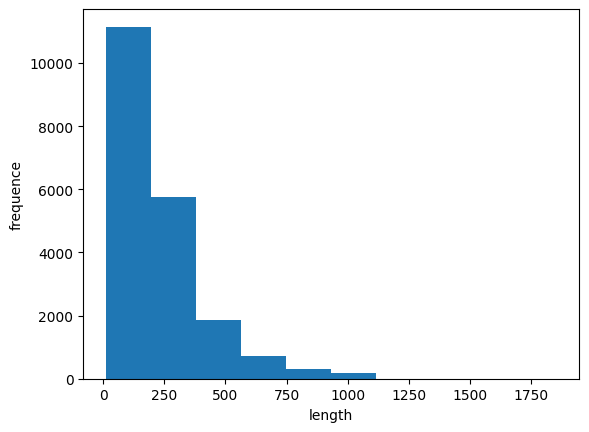

In [37]:
#histogram분포 빈도수
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequence')
plt.show()

---
###sequence padding(기회? 맞추기?/메꾸기)
#100보다 작은것은 버림

In [38]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq=pad_sequences(train_input,maxlen=100)
val_seq=pad_sequences(val_input,maxlen=100)

In [39]:
#크기 확인
train_seq.shape#0으로 채운다.

(20000, 100)

In [40]:
#첫번째 댓글 확인
print(train_seq[0])#문장의 시작이면 1

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [41]:
#원본데이터
print(train_input[0][-10:])#원본이 클 경우 앞을 자름

[6, 2, 46, 7, 14, 20, 10, 10, 470, 158]


In [42]:
print(train_seq[5])#100개의 단어가 어쩌구~

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


----
####LSTM 신경망 모델만들기

In [43]:
from tensorflow import keras
model=keras.Sequential()
model.add(keras.layers.Embedding(500,16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1,activation='sigmoid'))

model.build(input_shape=(None,100))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
#테스트 세트
test_seq = pad_sequences(test_input, maxlen=100)
print(train_seq.shape,val_seq.shape,test_seq.shape)#원핫인코딩과 전혀 상관없음

(20000, 100) (5000, 100) (25000, 100)


In [45]:
model.summary()#500*16??=8000

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

#LSTM 신경망 훈련하기

In [46]:
#compile
rmsprop=keras.optimizers.RMSprop(learning_rate=1e-4)#0.0001
model.compile(
    optimizer=rmsprop,#adam도 가능
    loss='binary_crossentropy',
    metrics=['accuracy']
)
checkpoint_cb=keras.callbacks.ModelCheckpoint("../Data/best-lstm-model.keras")#저장 내가 안해 너가 돌려보고 좋은거 저장해줘
early_stopping_cb=keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history=model.fit(
    train_seq,
    train_target,
    epochs=100,
    batch_size=32,
    validation_data=(val_seq, val_target),
    callbacks=[checkpoint_cb,early_stopping_cb]
)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5430 - loss: 0.6921 - val_accuracy: 0.6036 - val_loss: 0.6899
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6526 - loss: 0.6779 - val_accuracy: 0.6968 - val_loss: 0.6446
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7102 - loss: 0.5933 - val_accuracy: 0.7176 - val_loss: 0.5696
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7412 - loss: 0.5484 - val_accuracy: 0.7502 - val_loss: 0.5350
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7635 - loss: 0.5171 - val_accuracy: 0.7664 - val_loss: 0.5096
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7788 - loss: 0.4927 - val_accuracy: 0.7800 - val_loss: 0.4893
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7880 - loss: 0.4738 - val_accuracy: 0.7868 - val_loss: 0.4724
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7940 - loss: 0.4593 - val_accu

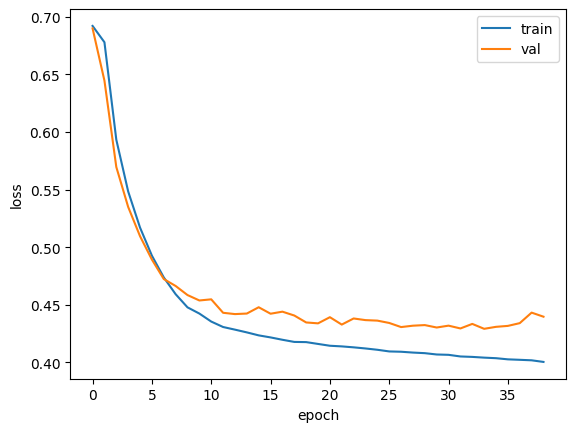

In [47]:
#시각화 해보기
# plt.plot(history.history['loss'])#train
# plt.plot(history.history['val_loss'])#valdata
# plt.legend('train','val')
# plt.show()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [48]:
val_loss,val_acc= model.evaluate(val_seq,val_target)
test_loss,test_acc=model.evaluate(test_seq, test_target)

print(f"검증세트-loss:{val_loss:.4f}, accuracy:{val_acc:.4f}")
print(f"테스트세트-loss:{test_loss:.4f}, accuracy:{test_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7998 - loss: 0.4292
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8048 - loss: 0.4241
검증세트-loss:0.4292, accuracy:0.7998
테스트세트-loss:0.4241, accuracy:0.8048


----
####DropOut 

In [49]:
from tensorflow import keras
model=keras.Sequential()
model.add(keras.layers.Embedding(500,16, input_length=100))
model.add(keras.layers.LSTM(8, dropout=0.3))
model.add(keras.layers.Dense(1,activation='sigmoid'))

model.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
#compile
rmsprop=keras.optimizers.RMSprop(learning_rate=1e-4)#0.0001
model.compile(
    optimizer=rmsprop,#adam도 가능
    loss='binary_crossentropy',
    metrics=['accuracy']
)
checkpoint_cb=keras.callbacks.ModelCheckpoint("../Data/best-lstm-model.keras")#저장 내가 안해 너가 돌려보고 좋은거 저장해줘
early_stopping_cb=keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history=model.fit(
    train_seq,
    train_target,
    epochs=100,
    batch_size=32,
    validation_data=(val_seq, val_target),
    callbacks=[checkpoint_cb,early_stopping_cb]
)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5400 - loss: 0.6922 - val_accuracy: 0.6086 - val_loss: 0.6907
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6047 - loss: 0.6866 - val_accuracy: 0.6726 - val_loss: 0.6775
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6819 - loss: 0.6301 - val_accuracy: 0.7164 - val_loss: 0.5821
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7171 - loss: 0.5682 - val_accuracy: 0.7430 - val_loss: 0.5450
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7485 - loss: 0.5311 - val_accuracy: 0.7576 - val_loss: 0.5129
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7654 - loss: 0.5027 - val_accuracy: 0.7706 - val_loss: 0.4925
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7794 - loss: 0.4793 - val_accuracy: 0.7852 - val_loss: 0.4708
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7894 - loss: 0.4647 - val

In [ ]:
val_loss,val_acc= model.evaluate(val_seq,val_target)
test_loss,test_acc=model.evaluate(test_seq, test_target)

print(f"검증세트-loss:{val_loss:.4f}, accuracy:{val_acc:.4f}")
print(f"테스트세트-loss:{test_loss:.4f}, accuracy:{test_acc:.4f}")
#모델 앞에 데이터 만드는 것이 제일 중요 500개의 데이터 